# 共享单车租用影响因素分析

实验背景：
本实验基于共享单车数据集，对影响租车数量的因素进行分析。包括天气，温度，时间，风速，湿度，季节因素，从而找出关键影响

数据来源：Kaggle Bike Sharing Demand

数据字段包括：
- datetime：时间
- temp：温度
- humidity：湿度
- windspeed：风速
- count：租车总人数

In [202]:
# 导入需要的库
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 解决中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv("share bike.csv")

# 检查数据是否读成功
print("数据的形状（行数, 列数）：", df.shape)
print("\n数据前5行：")
df.head()
display(df.head())

数据的形状（行数, 列数）： (10886, 12)

数据前5行：


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 数据基本情况与预处理

在正式分析影响共享单车租用数量的因素之前，首先对数据进行基本检查，包括数据规模、字段名称、缺失值和重复值情况。随后将 datetime 字段转换为时间格式，并从中提取小时、月份和星期几等特征，便于后续从时间维度分析租车数量变化。

In [203]:
# 查看数据基本情况
print("数据的形状（行数、列数）：", df.shape)

print("\n数据字段名称：")
print(df.columns)

print("\n缺失值统计：")
print(df.isnull().sum())

print("\n重复值数量：", df.duplicated().sum())

数据的形状（行数、列数）： (10886, 12)

数据字段名称：
Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='str')

缺失值统计：
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

重复值数量： 0


In [204]:
# 把日期列转换成时间格式
df['datetime'] = pd.to_datetime(df['datetime'])

# 提取时间特征：小时、月份、星期几
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

# 查看处理后的数据
print("预处理完成！新增了hour、month、weekday列")
df[['datetime', 'hour', 'month', 'weekday', 'count']].head()

预处理完成！新增了hour、month、weekday列


,datetime,hour,month,weekday,count
0,2011-01-01 00:00:00,0,1,5,16
1,2011-01-01 01:00:00,1,1,5,40
2,2011-01-01 02:00:00,2,1,5,32
3,2011-01-01 03:00:00,3,1,5,13
4,2011-01-01 04:00:00,4,1,5,1


### 数据基本情况分析

通过对数据进行检查可以看出，本数据集共有 10886 条记录，包含 datetime、season、holiday、workingday、weather、temp、atemp、humidity、windspeed、casual、registered、count 等字段。数据中没有发现缺失值和重复值，因此可以直接进行后续分析。

为了从时间维度研究共享单车租用数量的变化情况，本文将 datetime 字段转换为日期时间格式，并提取 hour、month、weekday 三个新字段。其中 hour 用于分析一天中不同时段的租车变化，month 用于分析不同月份的租车变化，weekday 用于分析一周中不同日期的租车变化。

从字段含义来看，count 表示每小时总租车人数，casual 表示非注册用户租车人数，registered 表示注册用户租车人数。后续分析主要以 count 作为因变量，研究天气、温度、湿度、风速和时间等因素对租车数量的影响。

## 时间对租车数量的影响

 不同小时的平均租车数量：
hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: count, dtype: float64


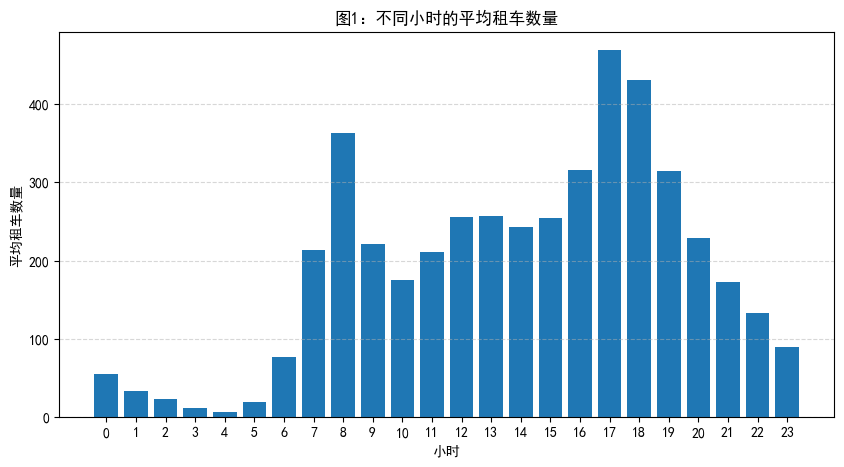

In [205]:


hour_avg = df.groupby('hour')['count'].mean()

# 输出每个小时的平均租车数量，方便后续写结论
print(" 不同小时的平均租车数量：")
print(hour_avg)

# 绘制柱状图
plt.figure(figsize=(10, 5))
plt.bar(hour_avg.index, hour_avg.values)

plt.title("图1：不同小时的平均租车数量")
plt.xlabel("小时")
plt.ylabel("平均租车数量")
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


由图1可以看出，共享单车租用数量在一天内呈现明显的时间规律。凌晨 0 点到 5 点租车数量较低，其中 4 点左右达到最低值，说明夜间出行需求较少。早上 7 点到 9 点租车数量明显上升，8 点附近形成早高峰；下午 17 点到 18 点租车数量再次升高，并且晚高峰更加明显。

从具体数值来看，17 点的平均租车数量最高，约为 468.8；18 点约为 430.9；8 点约为 362.8，而凌晨 4 点仅约为 6.4。由此可以推测，共享单车的使用具有明显的通勤特征，早晚高峰与上班、下班时间基本一致，其中下班时段的使用需求更强。


## 温度对租车数量的影响

不同温度区间的平均租车数量：
temp_group
0-10℃      73.185862
10-15℃    131.797095
15-20℃    171.267885
20-25℃    209.965385
25-30℃    235.819432
30-35℃    334.538535
35℃以上     332.834197
Name: count, dtype: float64

不同温度区间的样本数量：
temp_group
0-10℃     1259
10-15℃    2134
15-20℃    1915
20-25℃    2080
25-30℃    2254
30-35℃    1051
35℃以上      193
Name: count, dtype: int64


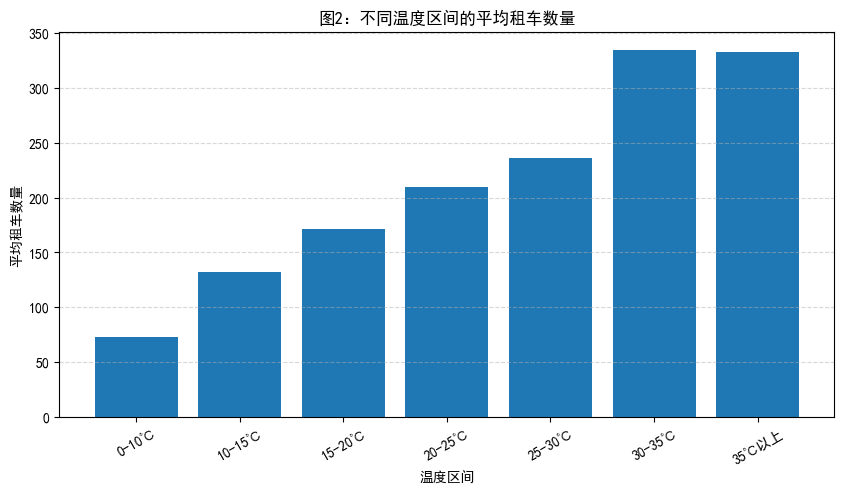

In [206]:

temp_bins = [0, 10, 15, 20, 25, 30, 35, 45]
temp_labels = ['0-10℃', '10-15℃', '15-20℃', '20-25℃', '25-30℃', '30-35℃', '35℃以上']

df['temp_group'] = pd.cut(df['temp'], bins=temp_bins, labels=temp_labels, include_lowest=True)

temp_avg = df.groupby('temp_group')['count'].mean()
temp_count = df.groupby('temp_group')['count'].count()

print("不同温度区间的平均租车数量：")
print(temp_avg)

print("\n不同温度区间的样本数量：")
print(temp_count)

plt.figure(figsize=(10, 5))
plt.bar(temp_avg.index.astype(str), temp_avg.values)

plt.title("图2：不同温度区间的平均租车数量")
plt.xlabel("温度区间")
plt.ylabel("平均租车数量")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

由图2可以看出，温度对共享单车租用数量有较明显影响。整体来看，随着温度升高，平均租车数量呈现先上升后趋于稳定或略有下降的趋势。当温度较低时，骑行舒适度较差，租车数量相对较少；当温度处于 20℃ 到 35℃ 左右时，平均租车数量明显增加，说明较温暖的天气更适合骑行。

但是，当温度继续升高到 35℃ 以上时，平均租车数量没有继续明显增加，可能是因为高温天气会降低人们的骑行意愿。因此，温度对共享单车使用具有一定促进作用，但这种影响并不是无限增加的，而是存在较适宜的温度范围。

## 风速对租车数量的影响

不同风速区间的平均租车数量和样本数量：


,mean,count
windspeed_group,,
0-5,161.101295,1313
5-10,165.660278,3026
10-15,202.255836,2099
15-20,216.005418,2953
20-25,199.880805,646
25-30,224.587678,422
30-35,205.103571,280
35-40,209.906542,107
40-50,160.000000,36


风速与租车数量的相关系数： 0.10136947021033275


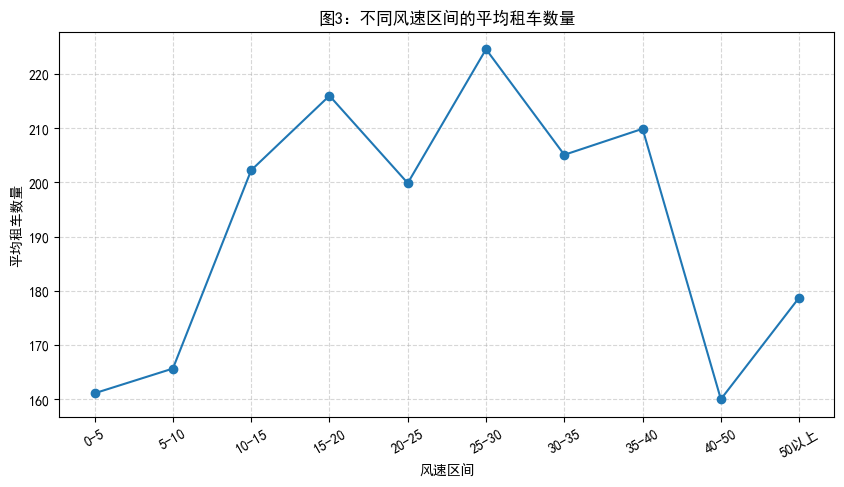

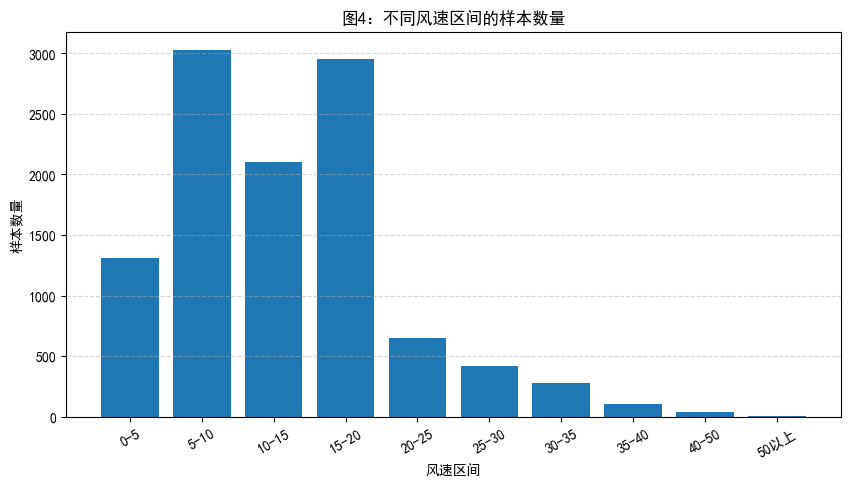

In [207]:


# 按风速划分区间
wind_bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
wind_labels = ['0-5', '5-10', '10-15', '15-20', '20-25',
               '25-30', '30-35', '35-40', '40-50', '50以上']

df['windspeed_group'] = pd.cut(
    df['windspeed'],
    bins=wind_bins,
    labels=wind_labels,
    include_lowest=True
)

# 计算每个风速区间的平均租车数量和样本数量
wind_result = df.groupby('windspeed_group')['count'].agg(['mean', 'count'])

print("不同风速区间的平均租车数量和样本数量：")
display(wind_result)

# 计算风速和租车数量的相关系数
wind_corr = df['windspeed'].corr(df['count'])
print("风速与租车数量的相关系数：", wind_corr)

# 图3：不同风速区间的平均租车数量，适合用折线图观察趋势
plt.figure(figsize=(10, 5))
plt.plot(wind_result.index.astype(str), wind_result['mean'], marker='o')

plt.title("图3：不同风速区间的平均租车数量")
plt.xlabel("风速区间")
plt.ylabel("平均租车数量")
plt.xticks(rotation=30)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 图4：不同风速区间的样本数量，用于判断结论是否可靠
plt.figure(figsize=(10, 5))
plt.bar(wind_result.index.astype(str), wind_result['count'])

plt.title("图4：不同风速区间的样本数量")
plt.xlabel("风速区间")
plt.ylabel("样本数量")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


由图3可以看出，不同风速区间下的平均租车数量存在一定波动，但整体趋势并不像时间、温度和天气因素那样明显。风速较低和中等风速区间的平均租车数量差异不大，说明在一般风速条件下，风速对共享单车使用量的影响相对有限。

结合图4可以发现，不同风速区间的样本数量差异较大，部分高风速区间的样本数量较少，因此这些区间的平均租车数量容易受到个别数据影响，不能直接得出“风速越大，租车数量越少”的简单结论。从相关系数来看，风速与租车数量之间的线性相关关系较弱，说明风速不是本数据集中影响租车数量的主要因素。相比之下，时间、温度和天气对租车数量的影响更加明显。


## 天气对租车数量的影响

不同天气下的平均租车数量和样本数量：


,mean,count
weather,,
晴天/多云,205.236791,7192
雾天/阴天,178.955540,2834
小雨/小雪,118.846333,859
大雨/大雪,164.000000,1


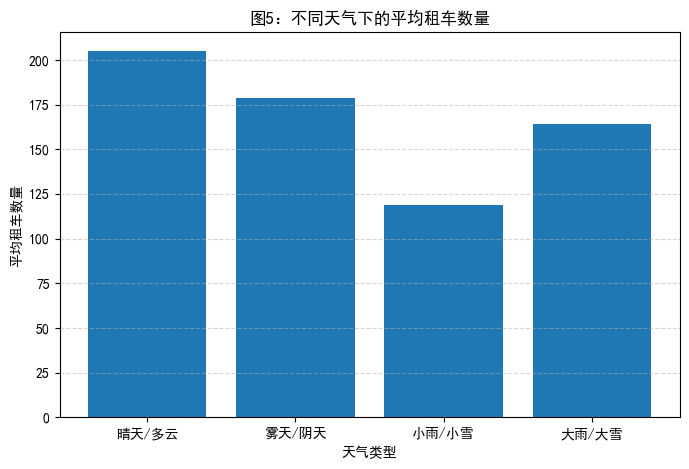

In [208]:

weather_map = {
    1: '晴天/多云',
    2: '雾天/阴天',
    3: '小雨/小雪',
    4: '大雨/大雪'
}

# 计算不同天气下的平均租车数量和样本数量
weather_result = df.groupby('weather')['count'].agg(['mean', 'count'])
weather_result.index = weather_result.index.map(weather_map)

print("不同天气下的平均租车数量和样本数量：")
display(weather_result)

# 绘制不同天气下的平均租车数量
plt.figure(figsize=(8, 5))
plt.bar(weather_result.index, weather_result['mean'])

plt.title("图5：不同天气下的平均租车数量")
plt.xlabel("天气类型")
plt.ylabel("平均租车数量")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

由图5可以看出，天气状况对共享单车租用数量有明显影响。在晴天或多云天气下，平均租车数量最高；在雾天、阴天条件下，平均租车数量有所下降；在小雨或小雪天气下，平均租车数量进一步减少。这说明天气越不适合户外出行，人们选择骑行共享单车的意愿越低。

从样本数量来看，天气类型 1、2、3 的样本数量较多，因此这些类别之间的比较相对可靠。但是天气类型 4 的样本数量极少，不能仅根据其平均值直接判断大雨、大雪天气下的真实租车需求。综合来看，天气是影响共享单车租用数量的重要因素，但在分析极端天气时需要结合样本数量谨慎判断。


## 拓展一：湿度对租车数量的影响

不同湿度区间的平均租车数量和样本数量：


,mean,count
humidity_group,,
0-20,180.384615,78
20-40,290.648718,1560
40-60,220.543490,3564
60-80,171.275872,3382
80-100,109.783666,2302


湿度与租车数量的相关系数： -0.3173714788765944


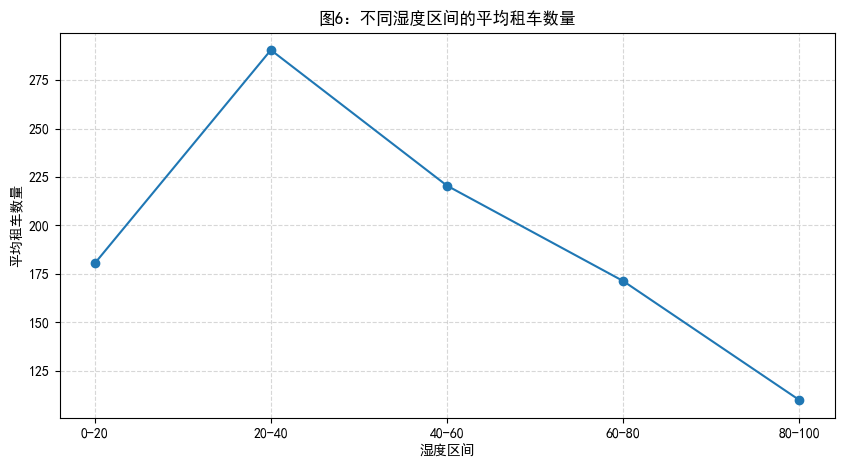

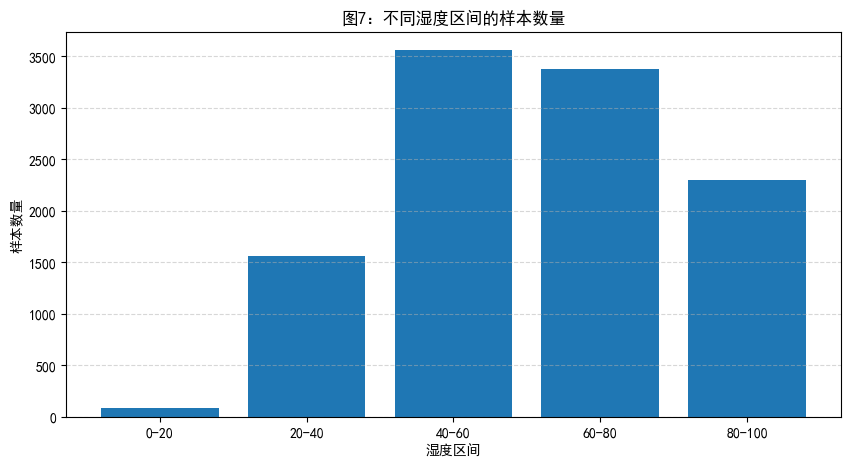

In [209]:

# 按湿度划分区间
humidity_bins = [0, 20, 40, 60, 80, 100]
humidity_labels = ['0-20', '20-40', '40-60', '60-80', '80-100']

df['humidity_group'] = pd.cut(
    df['humidity'],
    bins=humidity_bins,
    labels=humidity_labels,
    include_lowest=True
)

# 计算不同湿度区间的平均租车数量和样本数量
humidity_result = df.groupby('humidity_group')['count'].agg(['mean', 'count'])

print("不同湿度区间的平均租车数量和样本数量：")
display(humidity_result)

# 计算湿度和租车数量的相关系数
humidity_corr = df['humidity'].corr(df['count'])
print("湿度与租车数量的相关系数：", humidity_corr)

# 图6：不同湿度区间的平均租车数量
plt.figure(figsize=(10, 5))
plt.plot(humidity_result.index.astype(str), humidity_result['mean'], marker='o')

plt.title("图6：不同湿度区间的平均租车数量")
plt.xlabel("湿度区间")
plt.ylabel("平均租车数量")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 图7：不同湿度区间的样本数量
plt.figure(figsize=(10, 5))
plt.bar(humidity_result.index.astype(str), humidity_result['count'])

plt.title("图7：不同湿度区间的样本数量")
plt.xlabel("湿度区间")
plt.ylabel("样本数量")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


由图6可以看出，湿度对共享单车租用数量存在一定影响。整体来看，当湿度处于较低或中等水平时，平均租车数量相对较高；随着湿度升高，平均租车数量整体呈下降趋势。这说明湿度较高时，空气潮湿、体感闷热或可能伴随降雨，会降低用户骑行共享单车的意愿。

结合图7可以发现，不同湿度区间的样本数量并不完全相同，因此在分析时不能只看平均值，还需要考虑样本数量对结果稳定性的影响。从相关系数来看，湿度与租车数量之间存在一定负相关关系，但其影响仍需要结合天气、温度等因素共同判断。综合来看，湿度是影响共享单车租用数量的辅助因素，高湿度环境可能会降低骑行舒适度，从而减少租车需求。


## 拓展二：不同月份对租车数量的影响

不同月份的平均租车数量：


month
1      90.366516
2     110.003330
3     148.169811
4     184.160616
5     219.459430
6     242.031798
7     235.325658
8     234.118421
9     233.805281
10    227.699232
11    193.677278
12    175.614035
Name: count, dtype: float64

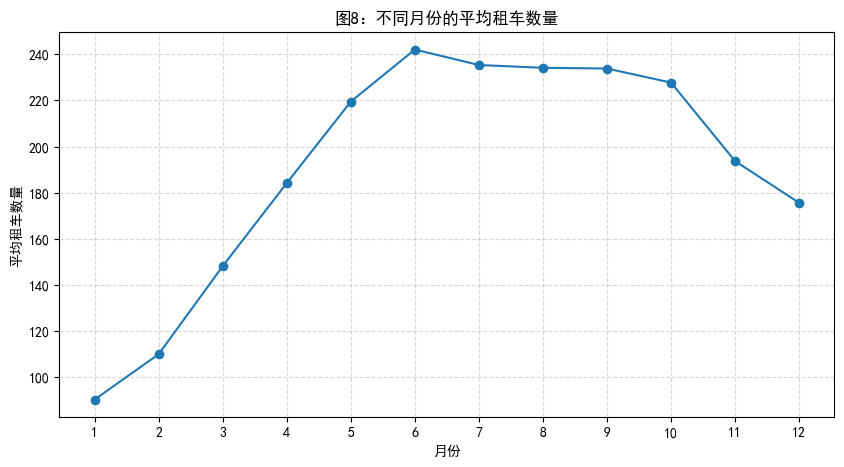

In [210]:

# 按月份统计平均租车数量
month_avg = df.groupby('month')['count'].mean()

print("不同月份的平均租车数量：")
display(month_avg)

# 绘制折线图
plt.figure(figsize=(10, 5))
plt.plot(month_avg.index, month_avg.values, marker='o')

plt.title("图8：不同月份的平均租车数量")
plt.xlabel("月份")
plt.ylabel("平均租车数量")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


由图8可以看出，共享单车租用数量在不同月份之间存在明显差异，整体呈现出一定的季节性变化。1月、2月等冬季或年初月份的平均租车数量较低，说明寒冷天气可能会降低人们骑行共享单车的意愿。随着月份推移，平均租车数量逐渐上升，在夏季和秋季月份保持较高水平，说明较温暖的气候条件更适合骑行。

这种变化趋势也与前面对温度因素的分析相互印证，即温度较适宜时，用户更愿意选择共享单车出行。因此，不同月份对租车数量的影响，本质上可能与季节、气温、天气舒适度等因素共同有关。

## 拓展三：工作日与非工作日对租车数量的影响

工作日与非工作日不同小时的平均租车数量：


,非工作日,工作日
hour,,
0,94.489655,36.732258
1,71.910345,16.003236
2,53.748252,8.436066
3,25.534722,4.892734
4,8.544828,5.363636
5,9.373239,24.529032
6,19.993103,102.577419
7,47.268966,290.690323
8,112.255172,479.945161


工作日与非工作日整体平均租车数量：


workingday
非工作日    188.506621
工作日     193.011873
Name: count, dtype: float64

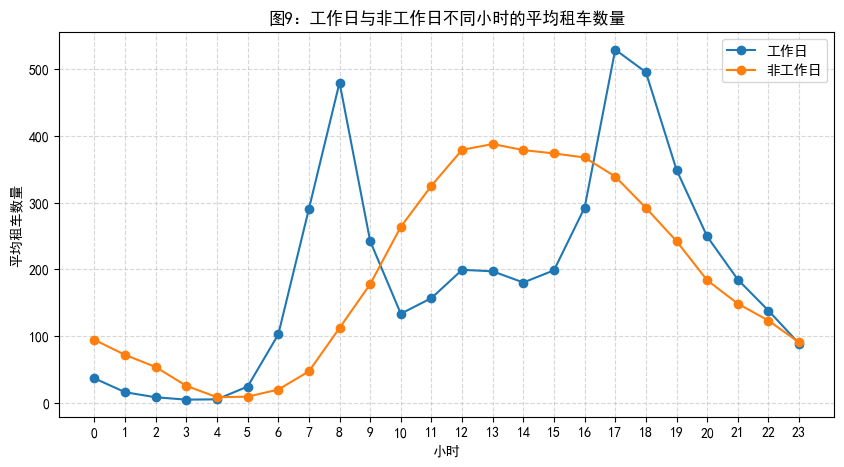

In [211]:

# 按小时和是否工作日统计平均租车数量
workday_hour = df.groupby(['hour', 'workingday'])['count'].mean().unstack()

# 修改列名，方便显示
workday_hour.columns = ['非工作日', '工作日']

print("工作日与非工作日不同小时的平均租车数量：")
display(workday_hour)

# 输出整体平均值
print("工作日与非工作日整体平均租车数量：")
display(df.groupby('workingday')['count'].mean().rename(index={0: '非工作日', 1: '工作日'}))

# 绘制折线图
plt.figure(figsize=(10, 5))

plt.plot(workday_hour.index, workday_hour['工作日'], marker='o', label='工作日')
plt.plot(workday_hour.index, workday_hour['非工作日'], marker='o', label='非工作日')

plt.title("图9：工作日与非工作日不同小时的平均租车数量")
plt.xlabel("小时")
plt.ylabel("平均租车数量")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


由图9可以看出，工作日和非工作日的共享单车使用规律存在明显差异。工作日的租车数量在早上 8 点和下午 17 点到 18 点附近出现明显高峰，其中 17 点平均租车数量最高，约为 529.2，18 点约为 495.5，8 点约为 479.9。这说明工作日共享单车使用具有较强的通勤特征。

非工作日的租车数量没有明显的早晚通勤高峰，而是从上午开始逐渐增加，在中午到下午时段保持较高水平，其中 13 点平均租车数量最高，约为 387.8。说明非工作日共享单车更多用于休闲、购物或短途出行。

虽然工作日和非工作日的整体平均租车数量差距不大，但二者在一天内的分布规律明显不同。因此，单纯比较总平均值并不能完全反映租车需求变化，还需要结合具体时间段进行分析。


## 拓展四：注册用户与非注册用户的租车规律对比


不同小时注册用户与非注册用户的平均租车数量：


,casual,registered
hour,,
0,10.312088,44.826374
1,6.513216,27.345815
2,4.819196,18.080357
3,2.681293,9.076212
4,1.262443,5.144796
5,1.455752,18.311947
6,4.149451,72.109890
7,10.914286,202.202198
8,21.542857,341.226374


注册用户、非注册用户和总租车人数的整体平均值：


casual         36.021955
registered    155.552177
count         191.574132
dtype: float64

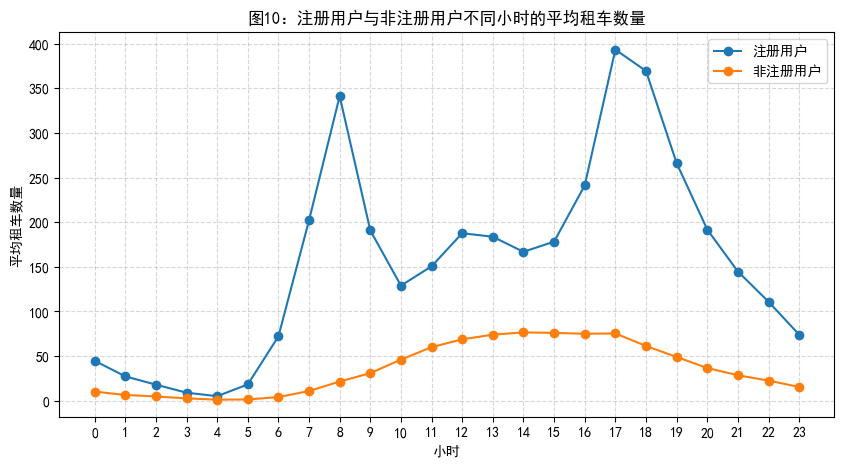

In [212]:

# 按小时统计 casual 和 registered 的平均租车数量
user_hour = df.groupby('hour')[['casual', 'registered']].mean()

print("不同小时注册用户与非注册用户的平均租车数量：")
display(user_hour)

print("注册用户、非注册用户和总租车人数的整体平均值：")
display(df[['casual', 'registered', 'count']].mean())

# 绘制折线图
plt.figure(figsize=(10, 5))

plt.plot(user_hour.index, user_hour['registered'], marker='o', label='注册用户')
plt.plot(user_hour.index, user_hour['casual'], marker='o', label='非注册用户')

plt.title("图10：注册用户与非注册用户不同小时的平均租车数量")
plt.xlabel("小时")
plt.ylabel("平均租车数量")
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


由图10可以看出，注册用户和非注册用户的租车规律存在明显差异。注册用户的平均租车数量明显高于非注册用户，整体平均来看，注册用户每小时平均租车数量约为 155.6，非注册用户约为 36.0，说明共享单车的主要使用群体是注册用户。

从一天内的变化规律来看，注册用户在早上 8 点和下午 17 点到 18 点附近出现明显高峰，其中 17 点注册用户平均租车数量约为 393.3，18 点约为 369.5，8 点约为 341.2。这与上下班时间基本一致，说明注册用户更多体现出通勤特征。

非注册用户的变化趋势相对平缓，主要集中在白天和下午时段，14 点到 17 点附近较高，但没有注册用户那样明显的早晚高峰。这说明非注册用户可能更多用于临时出行、休闲出行或短途游玩，而注册用户更可能形成稳定的日常使用习惯。


## 实验总结与个人思考

本实验基于共享单车租用数据，从时间、温度、天气、风速、工作日与非工作日、用户类型、月份和湿度等多个维度分析了影响共享单车租用数量的因素。通过对比不同因素下的平均租车数量，可以发现共享单车的租用情况并不是由单一因素决定的，而是受到时间规律、天气状况、气候舒适度和用户出行习惯等多方面因素共同影响。

从时间因素来看，共享单车租用数量在一天中呈现明显的早晚高峰，尤其是工作日的 8 点、17 点和 18 点附近租车数量较高，说明共享单车具有明显的通勤属性。进一步比较工作日和非工作日可以发现，工作日早晚高峰更加突出，而非工作日的租车数量更多集中在白天和下午，说明非工作日的使用场景可能更偏向休闲、购物或短途出行。

从气候因素来看，温度、天气和湿度都会影响共享单车的使用。温度较低时，平均租车数量较少；温度升高到较舒适区间后，租车数量明显增加。晴天或多云天气下租车数量较高，而小雨、小雪等天气下租车数量下降。湿度较高时，平均租车数量也整体下降，说明不舒适的天气环境会降低用户骑行意愿。

在风速分析中，我发现风速与租车数量之间的关系并不如一开始想象得明显。部分高风速区间样本数量较少，因此不能简单得出“风速越大，租车数量越少”的结论。这说明在数据分析中，不能只看图形趋势或平均值，还需要结合样本数量和相关系数进行判断。

从用户类型来看，注册用户的平均租车数量明显高于非注册用户，并且注册用户在早晚高峰时段的变化更加明显，说明注册用户更可能形成稳定的日常通勤习惯；非注册用户的租车时间分布相对平缓，可能更多用于临时出行或休闲出行。

通过本次实验，我认识到数据分析不仅是画出图表，更重要的是根据图表和数据得出合理解释。在分析过程中，需要注意样本数量是否充足、结论是否有数据支撑，以及不同因素之间是否可能相互影响。例如月份变化与温度变化有关，天气变化也可能影响湿度，因此不能孤立地看待某一个因素。总体来看，时间因素、温度因素和天气因素对共享单车租用数量的影响最明显，风速和湿度也有一定影响，但需要结合样本数量谨慎分析。
